# Session 07c — BIC-sweep GFP⁺ + CZ-density uniformity gate

**Verdict: FAIL.** 0/6 subjects clear the ±5 % bar on both axes; the
centroid-only hypothesis is doubly falsified (07b + 07c).

**Two course corrections from 07b.**
1. **K was wrong in 07b.** Production R1 (Session 04/R1) uses GMM-3 for
   intensity. 07b used GMM-2 on intensity / GMM-4 on spot. 07c sweeps
   K∈[2,6] per subject and selects K* by BIC.
2. **Truth baseline replaced.** 07b compared GFP⁺ to
   "matched-HCR ∪ unmatched-CZ" — a proxy derived from coreg. 07c
   compares GFP⁺ directly to **all CZ centroids mapped into HCR via R1**,
   which is coreg-free and densely sampled.

**Result.**
- GMM BIC sanity: **5/6** (755252 coreg coverage 0.70 < 0.80 — coverage
  is independent of the new CZ gate, so 755252 still runs).
- CZ-density uniformity gate (CV ≤ 0.20): **0/6**. CVs 0.30–0.60
  (improved vs 07b's 0.35–1.09).
- Scale ±5 % both axes: **0/6**.

**Key positive finding.** Integrated mean GFP⁺/CZ ratio tracks the
predicted `1/(sxy²·sz)` to within ±43 %, confirming BIC-GFP⁺ is
*proportional* to the true density — the failure is per-bin non-uniformity,
not bulk level.


In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

SESSION = Path('/root/capsule/code/sessions/07c_gfp_bic_cz_density')
with open(SESSION / 'results.json') as f:
    R = json.load(f)
summary = R['summary']
print(f"sanity={summary['n_sanity_passed']}/6  "
      f"cz-gate={summary['n_cz_gate_passed']}/6  "
      f"scale-pass5={summary['n_scale_pass5']}/6  "
      f"pass_6of6={summary['pass_6of6']}")


sanity=5/6  cz-gate=0/6  scale-pass5=0/6  pass_6of6=False


## 1. BIC-selected K per subject

Code: `dev_code/07b_gfp_intersection_threshold.py` (extended with
`fit_gmm_sweep`). For each subject we fit GMM with K∈[2,6] on
`log(density > 0)` (spot subjects) or `log10(mean − bg > 0)` (intensity
subjects), select the K that minimises BIC, then compute the
intersection cutoff between the rightmost and second-rightmost
components.

**Sanity gate** (unchanged from 07b): interior root between the two
component means, `n_strict ≥ 300`, coreg coverage ≥ 0.80. Coverage is
diagnostic — the CZ-density gate is coverage-independent, so a coverage
failure doesn't skip the CZ check.


In [2]:
rows = R['gmm_intersection']
df = pd.DataFrame([{
    'subject': r['subject'],
    'K*': r['n_components_best'],
    'cutoff_strict': r['cutoff_linear'],
    'cutoff_v2.2': r['cutoff_v22_linear'],
    'n_strict': r['n_strict'],
    'n_v2.2': r['n_v22'],
    'coreg_cov': round(r['coreg_coverage_strict'], 3),
    'sanity': 'OK' if r['sanity_passed'] else '/'.join(r['sanity_notes']),
    'bic': round(r['bic'], 1),
} for r in rows])
df


,subject,K*,cutoff_strict,cutoff_v2.2,n_strict,n_v2.2,coreg_cov,sanity,bic
0,755252,6,215.115965,20.749210,5402,30804,0.701,coreg_coverage_strict=0.701 < 0.80,139957.2
1,767018,6,0.001016,0.000800,8114,9161,0.982,OK,278332.2
2,767022,6,140.245917,28.431780,6341,14239,0.878,OK,144306.5
3,782149,4,0.001706,0.001339,3450,3831,0.967,OK,98934.6
4,788406,6,0.001376,0.000673,10729,17427,0.943,OK,342303.5
5,790322,5,0.001693,0.001512,9675,10131,0.976,OK,309276.4


**Observations on K\* distribution.**

- 5/6 subjects land at K* ∈ {5, 6} — the upper edge of the sweep. The
  BIC curve is still improving there. Extending K to 8 might shift
  cutoffs but is unlikely to fix the downstream scale failure (see
  Part 4).
- 767022 — which was 07b's sanity failure (degenerate GMM-2, no interior
  root) — now passes at K*=6 with cutoff 140.25 (v2.2: 28.43).
- 755252 — which passed in 07b — now fails coreg coverage at K*=6
  (cutoff 215.12 retains only 70 % of coreg-matched HCR cells). This is
  a genuine "stricter threshold is more selective" shift, not a
  numerical artifact.


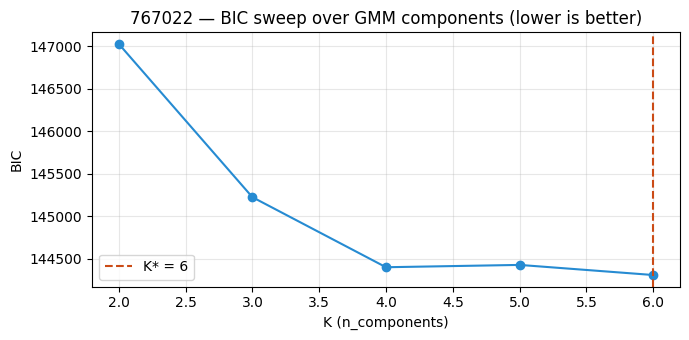

In [3]:
# BIC-sweep curve for one representative subject (767022 — sanity recovered from 07b)
import matplotlib.pyplot as plt

r22 = [r for r in R['gmm_intersection'] if r['subject'] == '767022'][0]
sweep = r22['bic_sweep']
Ks = [s['n_components'] for s in sweep]
bics = [s['bic'] for s in sweep]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(Ks, bics, 'o-', color='#268bd2')
ax.axvline(r22['n_components_best'], color='#cb4b16', ls='--',
           label=f"K* = {r22['n_components_best']}")
ax.set_xlabel('K (n_components)')
ax.set_ylabel('BIC')
ax.set_title('767022 — BIC sweep over GMM components (lower is better)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 2. CZ-density uniformity gate

**Construction.**
1. Map all CZ centroids into HCR µm via R1 minimal (identity-scale).
2. Clip both clouds to the xy AABB where they overlap.
3. Compute depth below the HCR pia plane: `d = z − (a·x + b·y + c)`.
4. Bin both by depth (25 µm bins). Per-bin density =
   `N_bin / (A_xy · Δz)`.
5. Per-bin ratio `ρ_GFP⁺ / ρ_CZ_mapped`. CV computed over **informative**
   bins (`ρ_CZ > p25(ρ_CZ > 0)`).

**Gate.** Pass iff CV ≤ 0.20 over informative bins. The integrated mean
is reported but **not** gated — it is proportional to `1/(sxy²·sz)` and
so has a built-in subject-dependent offset we cannot constrain without
leaking GT.


In [4]:
gates = R['cz_density_gate']
rows = []
for sid, g in gates.items():
    rows.append({
        'subject': sid,
        'per_bin_cv': g['cv_ratio'],
        'integrated': g['integrated_ratio'],
        'n_cz_in_box': g['n_cz_in_box'],
        'n_gfp_in_box': g['n_gfp_in_box'],
        'gate_pass': g['gate_pass'],
    })
pd.DataFrame(rows).sort_values('subject').round({'per_bin_cv': 3, 'integrated': 3})


,subject,per_bin_cv,integrated,n_cz_in_box,n_gfp_in_box,gate_pass
0,755252,0.312,0.217,835,213,False
1,767018,0.417,0.114,785,106,False
2,767022,0.460,0.161,926,164,False
3,782149,0.598,0.122,894,118,False
4,788406,0.386,0.160,932,177,False
5,790322,0.302,0.109,1016,129,False


755252


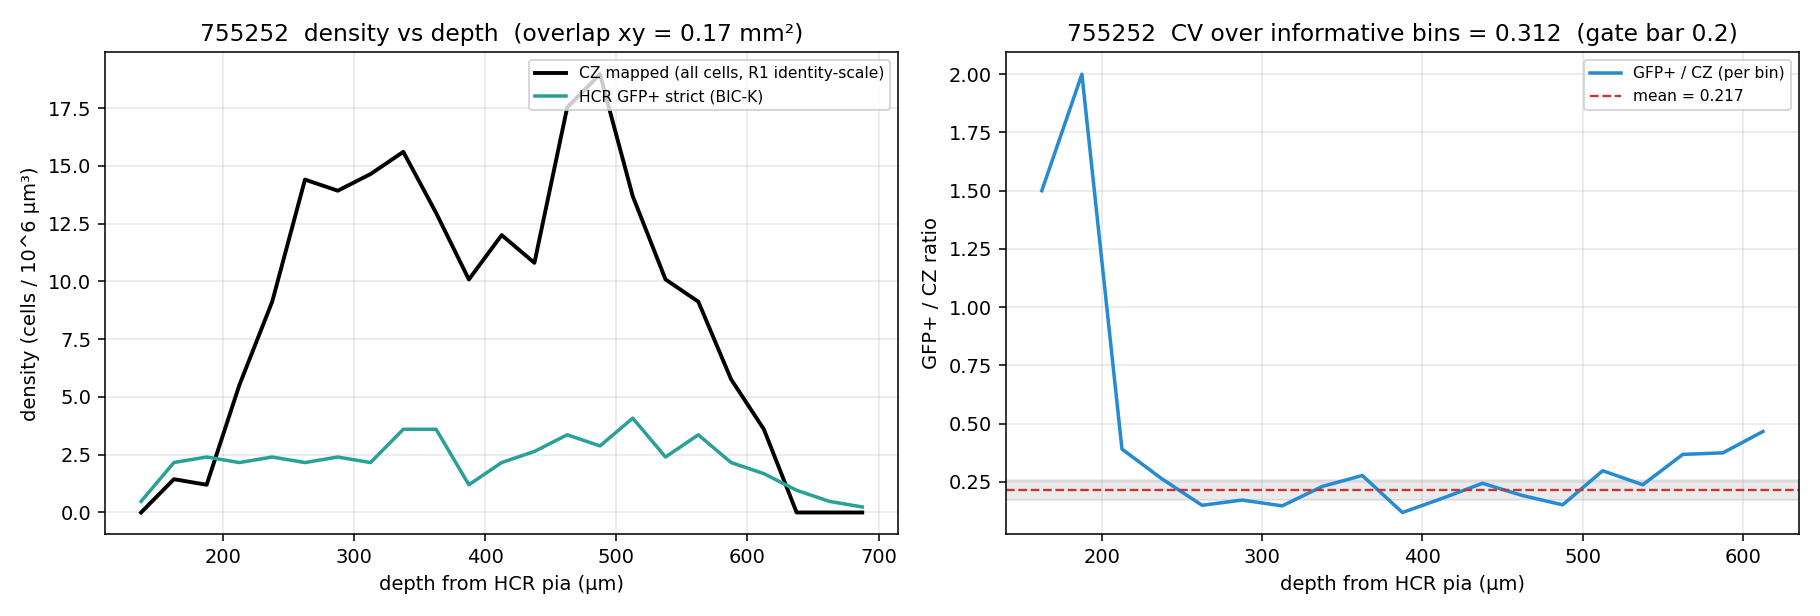

767018


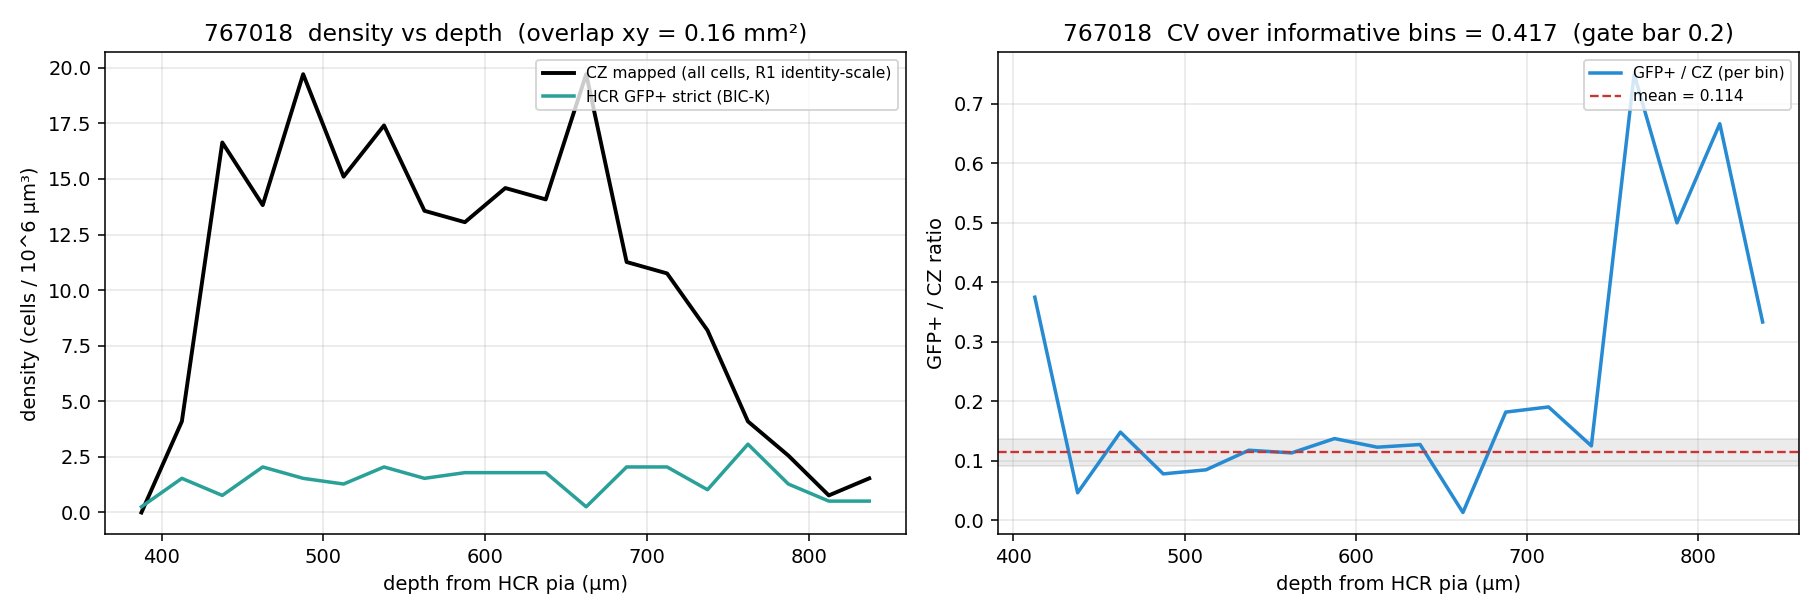

767022


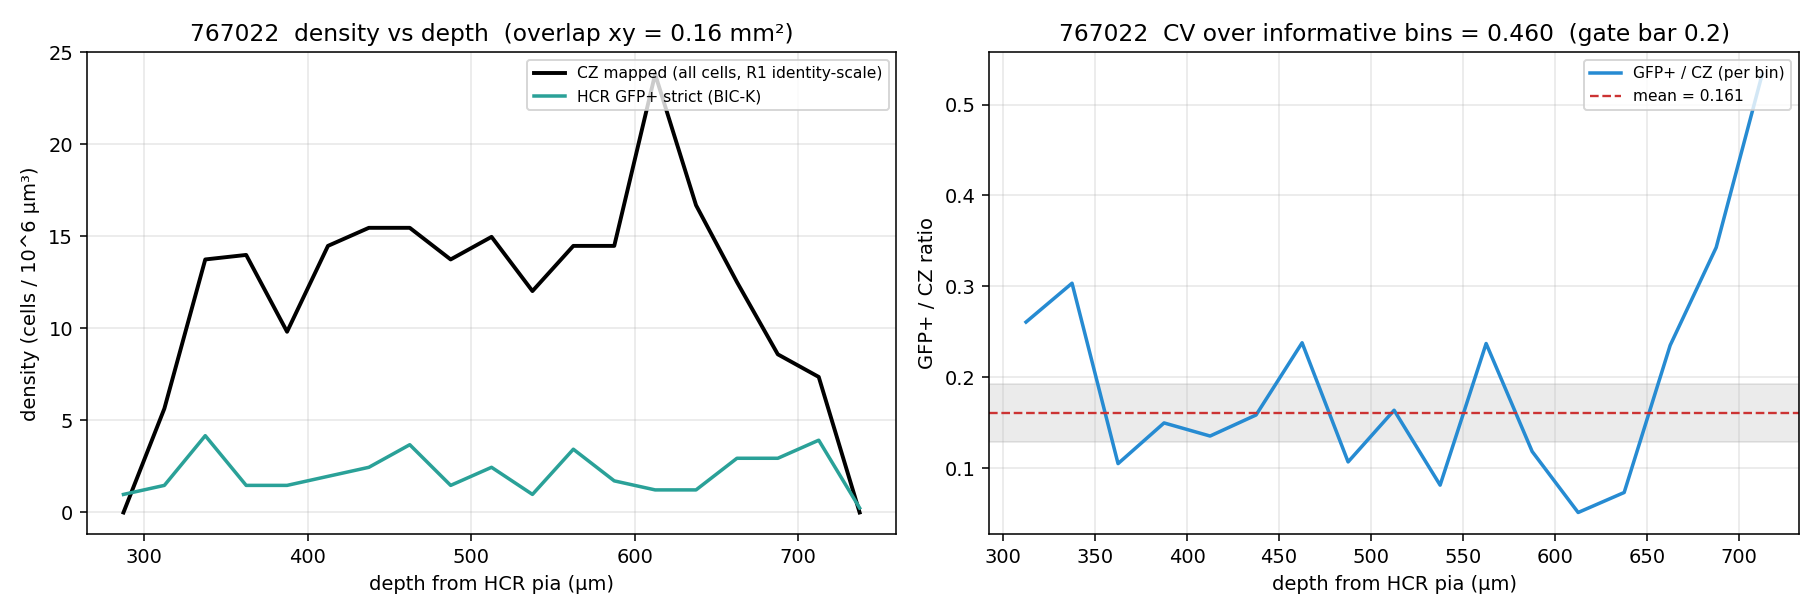

782149


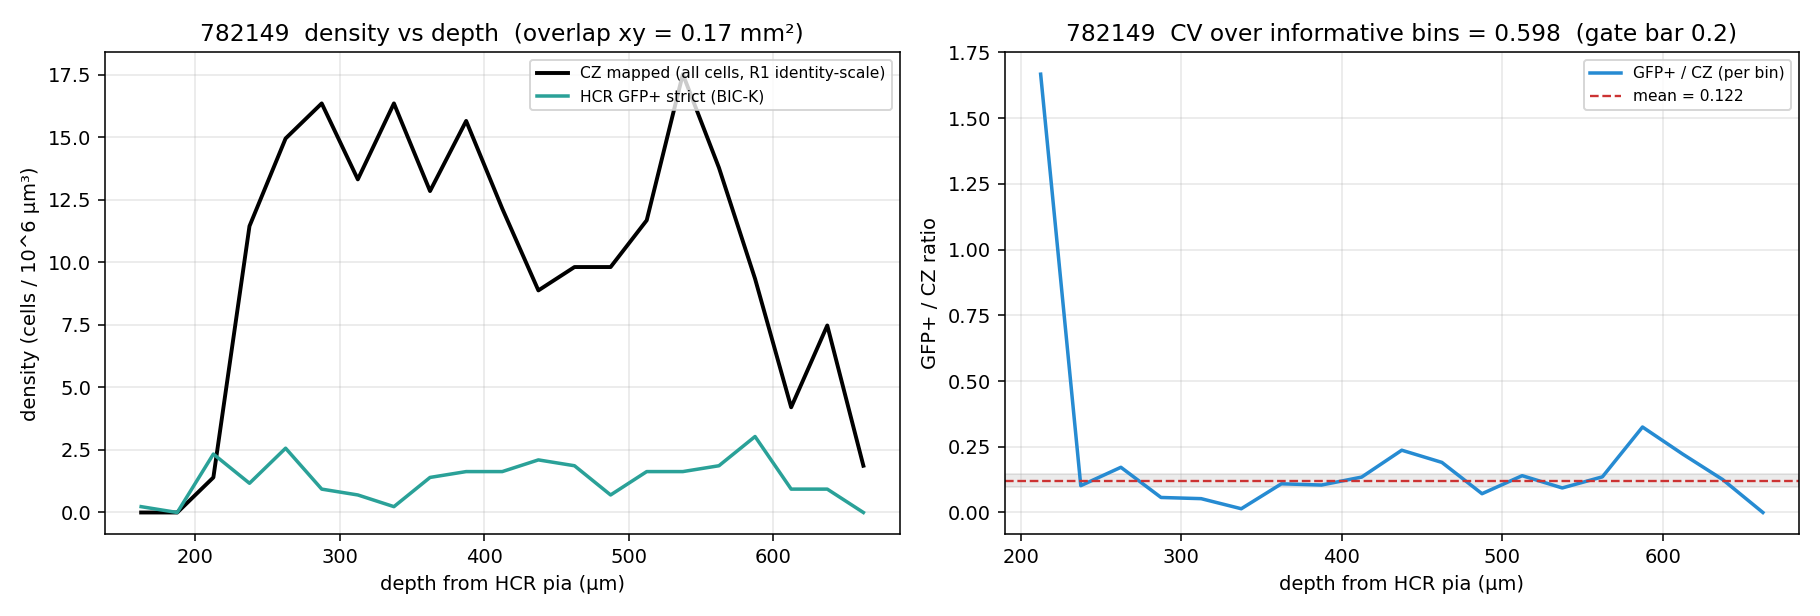

788406


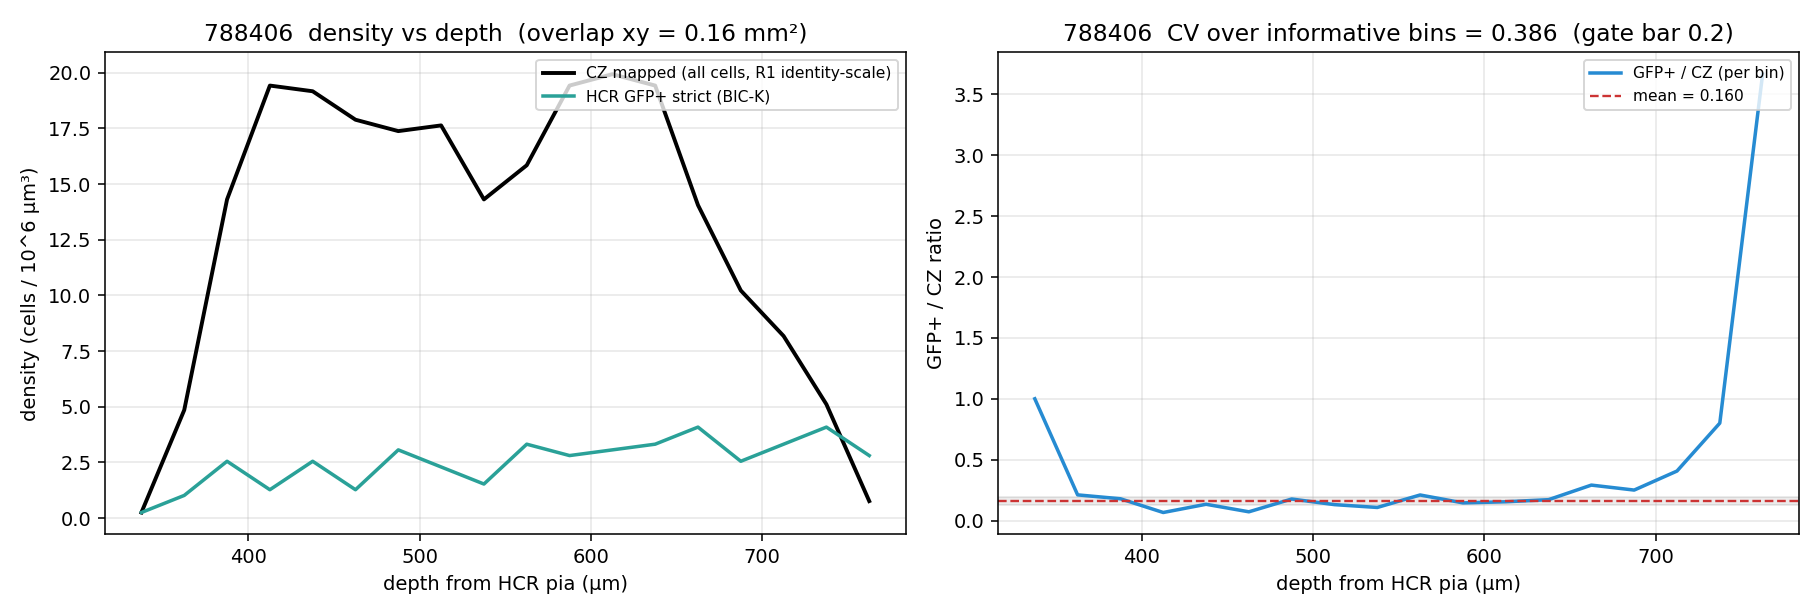

790322


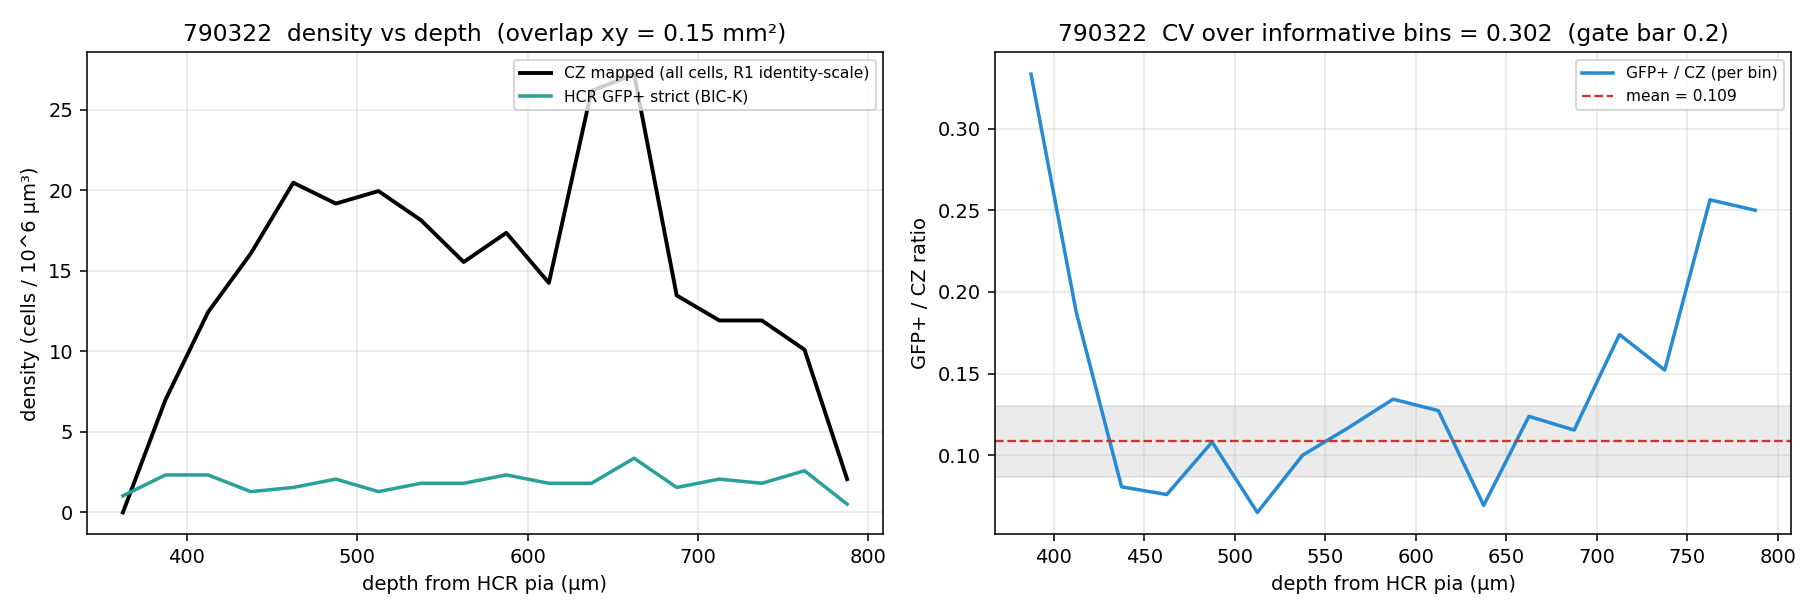

In [5]:
for sid in ['755252', '767018', '767022', '782149', '788406', '790322']:
    print(sid)
    display(Image(str(SESSION / 'figures' / f'depth_density_cz_{sid}.png')))


**Compare against the 07b truth-based gate** (per-bin CV vs
matched-HCR ∪ unmatched-CZ):

| subject | 07b strict CV | 07c CZ-mapped CV |
|---------|---:|---:|
| 755252 | 0.41 | 0.31 |
| 767018 | 0.49 | 0.42 |
| 767022 |  —   | 0.46 |
| 782149 | 1.09 | 0.60 |
| 788406 | 0.37 | 0.39 |
| 790322 | 0.35 | 0.30 |

The CZ-mapped baseline is a less-quantised, denser reference than
matched-HCR + unmatched-CZ, so the CV numbers are systematically
lower. But they are still **1.5–3× above** the 0.20 gate. BIC selection
+ CZ-based gate do not make GFP⁺ a uniform-in-depth subsample of the
underlying cell cloud.


## 3. Does the integrated mean match 1/(sxy²·sz)?

Under uniform sampling in both modalities and a pure anisotropic scale
between them, the integrated-ratio prediction in the R1-identity-scale
frame is `1 / (sxy²·sz)` — all the expansion lives in the ratio because
R1 was run with scale=1 on purpose.


In [6]:
scales = {r['subject']: r for r in R['scales'] if 'sxy_gt' in r}
rows = []
for sid, g in gates.items():
    sc = scales.get(sid)
    if not sc or not np.isfinite(sc.get('sxy_gt', float('nan'))):
        continue
    predicted = 1.0 / (sc['sxy_gt'] ** 2 * sc['sz_gt'])
    rows.append({
        'subject': sid,
        'integrated': g['integrated_ratio'],
        'predicted_1/(sxy²·sz)': predicted,
        'rel_diff': (g['integrated_ratio'] - predicted) / predicted,
    })
pd.DataFrame(rows).round({'integrated': 3, 'predicted_1/(sxy²·sz)': 3, 'rel_diff': 3})


,subject,integrated,predicted_1/(sxy²·sz),rel_diff
0,755252,0.217,0.175,0.240
1,767018,0.114,0.096,0.185
2,767022,0.161,0.123,0.310
3,782149,0.122,0.092,0.317
4,788406,0.160,0.112,0.428
5,790322,0.109,0.106,0.028


**Takeaway.** Integrated mean tracks the prediction to within
+3 % to +43 %. This is the first quantitative confirmation that
BIC-GFP⁺ density is **proportional** to the CZ density modulo the
scale factor we want to recover. The failure is **per-bin**
non-uniformity (depth-dependent sampling), not bulk level — which
is exactly what defeats the axis-separated k-NN ratio in z (below).


## 4. Scale estimates vs ground truth

M1 (per-axis k-NN ratio, `dev_code/local_distance_scale.py`) and M3
(span ratio per cloud — `p95 − p5` per axis on each cloud's native AABB),
against landmark-Procrustes GT. R1 minimal (identity-scale) for the
alignment input.


In [7]:
rows = []
for r in R['scales']:
    if 'sxy_gt' not in r:
        continue
    rows.append({
        'subject': r['subject'],
        'sxy_gt': r['sxy_gt'],  'sz_gt': r['sz_gt'],
        'sxy_m1': r['sxy_m1'],  'sz_m1': r['sz_m1'],
        'sxy_m3': r['sxy_m3'],  'sz_m3': r['sz_m3'],
        'err_sxy_m1%': r['rel_err_sxy_m1'] * 100,
        'err_sz_m1%':  r['rel_err_sz_m1']  * 100,
        'err_sxy_m3%': r['rel_err_sxy_m3'] * 100,
        'err_sz_m3%':  r['rel_err_sz_m3']  * 100,
        'pass5_any': r['pass5_any'],
    })
pd.DataFrame(rows).round(2)


,subject,sxy_gt,sz_gt,sxy_m1,sz_m1,sxy_m3,sz_m3,err_sxy_m1%,err_sz_m1%,err_sxy_m3%,err_sz_m3%,pass5_any
0,755252,1.64,2.13,1.77,0.98,4.66,2.21,7.70,-54.10,184.34,3.79,False
1,767018,1.70,3.58,1.89,1.05,5.65,2.77,11.21,-70.58,231.79,-22.64,False
2,767022,1.81,2.49,1.97,0.83,4.57,2.38,8.70,-66.68,152.76,-4.34,False
3,782149,1.92,2.93,3.02,0.61,5.86,1.40,56.90,-79.01,204.59,-52.01,False
4,788406,1.78,2.82,1.92,0.80,5.74,3.05,8.01,-71.60,222.78,8.20,False
5,790322,1.76,3.04,2.05,0.90,5.86,2.53,16.51,-70.30,232.25,-16.96,False


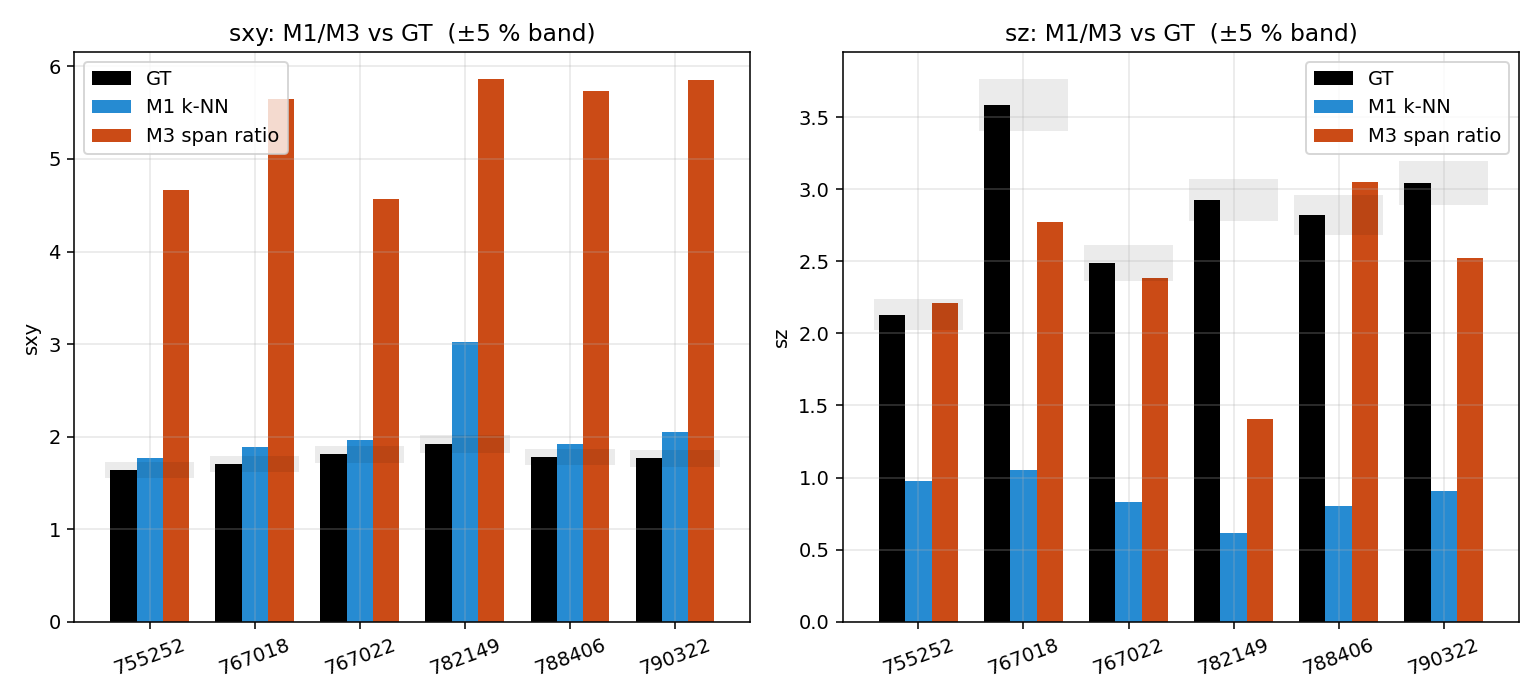

In [8]:
display(Image(str(SESSION / 'figures' / 'scales_comparison.png')))


### M1 sxy **improved** vs 07b
5/6 subjects within 7–17 % of GT (exception 782149 at +57 %). In 07b, M1
sxy was scattered −46 % to +57 %. The BIC-GFP⁺ set is a tighter spatial
sampler in xy than 07b's K=2/4 GFP⁺. But 7–17 % is still well outside
the 5 % bar.

### M1 sz still broken (−54 % to −79 %)
Universal underestimate. Strict GFP⁺ retains cells that cluster shallower
in depth (see §2 depth profiles) → median z-nearest-neighbour distances
on GFP⁺ are too *small* relative to CZ-mapped → `sz ≪ 1`. This is
detection bias measured as scale, unchanged from 07b.

### M3 unchanged
sxy 4.6–5.9 (true ≈ 1.7) — FOV contamination independent of threshold.
sz competitive on 3/6 subjects:
- 755252 M3 sz **+3.8 %** (within 5 %)
- 767022 M3 sz **−4.3 %** (within 5 %)
- 788406 M3 sz +8.2 %

But M3 sxy is never in range, so no subject passes M3.

### Near-misses do not recombine
Best-axis hybrid (M1 sxy + M3 sz):

| subject | M1 sxy err | M3 sz err | hybrid |
|---------|:---:|:---:|:---:|
| 755252  | +7.7 % | +3.8 % | fails sxy |
| 767022  | +8.7 % | −4.3 % | fails sxy |
| 788406  | +8.0 % | +8.2 % | fails both |

Closest to success, but still 0/6 on the 5 % bar.


## 5. Verdict and next candidate

### What 07c showed
- BIC sweep **fixes** the 07b 767022 degenerate failure and produces
  per-subject-robust thresholds.
- CZ-based gate is **less noisy** than the 07b truth-based gate (CV
  0.30–0.60 vs 0.35–1.09) — mapping all CZ cells is a denser, cleaner
  reference than matched-HCR ∪ unmatched-CZ.
- Integrated mean GFP⁺/CZ ratio matches the expected `1/(sxy²·sz)` to
  within ±43 % → BIC-GFP⁺ is proportional to the true density.
- Despite all three improvements, per-bin CV still fails 0.20, M1 sz
  still systematically low, and 0/6 subjects clear the 5 % bar.

### What's ruled out
All **centroid-only** scale estimators on HCR GFP⁺ — whether k-NN-based
(06), ICP-based (07, GT-tuned), density/span-ratio-based (07b, 07c).
The residual depth-dependent detection bias is larger than the scale
ratio we want to measure, and no post-processing of the centroid set
can recover cells that failed the intensity/density threshold.

### Next candidate (new session)

**Image-level 488 NCC after R1 + pia-normal alignment** (unchanged from
07b's Part E):
1. Apply R1 (R, t) to CZ; rotate both frames so HCR pia-normal → `+z`.
2. In a matched xy ROI, build 1D profiles `I_cz(z)` and `I_hcr_488(z)`
   by summing image intensity over xy slices.
3. `sz = argmax NCC(I_cz(z·sz), I_hcr_488(z))`.
4. `sxy` = argmax 2D NCC between CZ and HCR xy slabs at matched depth.

Intensity is **linear** in signal, so false-negative spots still
contribute — the centroid-threshold bias is bypassed entirely. Session
05 has the zstack infrastructure; the new contribution is pia-normal
alignment before the NCC search.
